WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
c:\Users\natna\Downloads\KAIM WEEK-11\Change-Point-Analysis-and-Statistical-Modeling-of-Time-Series-Data\.venv\Lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


Dataset loaded with 9011 records.


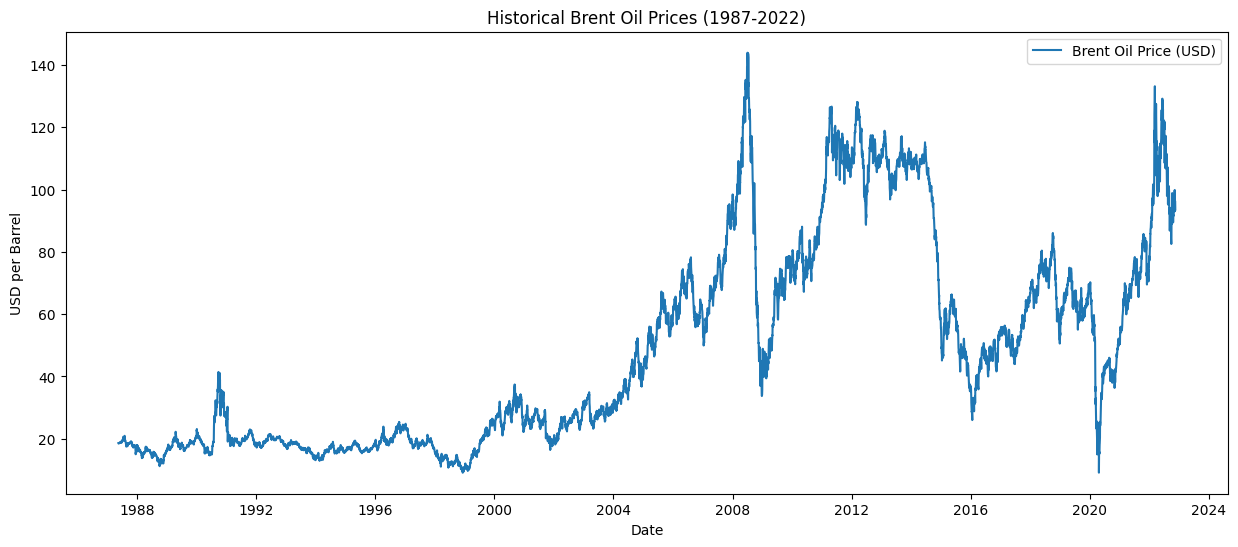

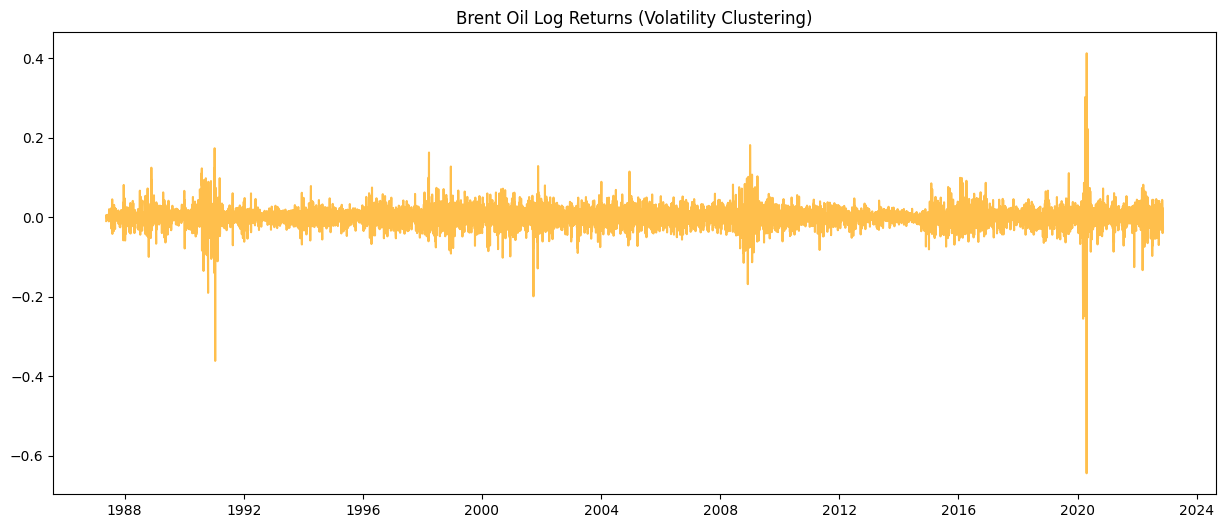

In [3]:
# --- Cell 1: Setup and Imports ---
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Add src to path to import your Task 1 scripts
sys.path.append(os.path.abspath('../src'))
from data_loader import load_brent_data

# --- Cell 2: Load and Prepare Data (Requirement 1.a.i) ---
df = load_brent_data('../data/raw/BrentOilPrices.csv')
print(f"Dataset loaded with {len(df)} records.")

# --- Cell 3: Plot Raw Price (Requirement 1.a.ii) ---
plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Price'], label='Brent Oil Price (USD)')
plt.title('Historical Brent Oil Prices (1987-2022)')
plt.xlabel('Date')
plt.ylabel('USD per Barrel')
plt.legend()
plt.show()

# --- Cell 4: Log Returns and Volatility (Requirement 1.a.iii & iv) ---
# Calculate log returns: log(price_t) - log(price_{t-1})
df['Log_Returns'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df = df.dropna()

plt.figure(figsize=(15, 6))
plt.plot(df.index, df['Log_Returns'], color='orange', alpha=0.7)
plt.title('Brent Oil Log Returns (Volatility Clustering)')
plt.show()


In [2]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

# Add src to path
sys.path.append(os.path.abspath('../src'))
from data_loader import load_brent_data

# Load the data - This defines the 'df' variable
df = load_brent_data('../data/raw/BrentOilPrices.csv')

# Requirement 1.a.iii: Calculate log returns
df['Log_Returns'] = np.log(df['Price']) - np.log(df['Price'].shift(1))
df = df.dropna()

print("Data loaded and 'df' is now defined.")

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


Data loaded and 'df' is now defined.


In [3]:
# Select a subset for clear change point detection (e.g., last 1000 days)
data_subset = df['Price'].iloc[-1000:].values
dates_subset = df.index[-1000:]
n_total = len(data_subset)
time_index = np.arange(n_total)

with pm.Model() as model:
    # i. Define the Switch Point (tau) [cite: 96]
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_total - 1)
    
    # ii. Define "Before" and "After" Parameters [cite: 97]
    mu_1 = pm.Normal("mu_1", mu=data_subset.mean(), sigma=10)
    mu_2 = pm.Normal("mu_2", mu=data_subset.mean(), sigma=10)
    
    # iii. Use a Switch Function [cite: 98]
    mu_ = pm.math.switch(tau > time_index, mu_1, mu_2)
    
    # iv. Define the Likelihood [cite: 99]
    sigma = pm.HalfNormal("sigma", sigma=5)
    observation = pm.Normal("obs", mu=mu_, sigma=sigma, observed=data_subset)
    
    # v. Run the Sampler [cite: 100]
    trace = pm.sample(1000, tune=1000, return_inferencedata=True)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [mu_1, mu_2, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1634 seconds.


         mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau   712.191  3.187  707.000  718.000      0.109    0.076     858.0   
mu_1   57.102  0.534   56.072   58.071      0.009    0.008    3740.0   
mu_2   97.640  0.858   95.958   99.186      0.017    0.013    2609.0   

      ess_tail  r_hat  
tau      710.0    1.0  
mu_1    2795.0    1.0  
mu_2    2444.0    1.0  


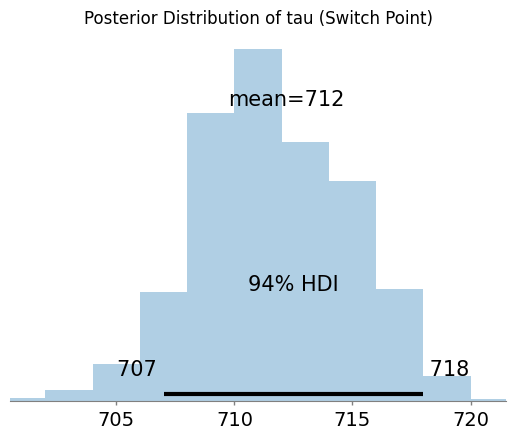

Mean before shift: $57.10
Mean after shift: $97.64


In [4]:
# i. Check for Convergence [cite: 101]
print(az.summary(trace, var_names=["tau", "mu_1", "mu_2"]))

# ii. Identify the Change Point [cite: 102]
az.plot_posterior(trace, var_names=["tau"])
plt.title("Posterior Distribution of tau (Switch Point)")
plt.show()

# iii. Quantify Impact [cite: 103, 107]
mu1_val = trace.posterior['mu_1'].mean().values
mu2_val = trace.posterior['mu_2'].mean().values
print(f"Mean before shift: ${mu1_val:.2f}")
print(f"Mean after shift: ${mu2_val:.2f}")

REPORT SUMMARY:
The Bayesian model identifies a structural break on 2021-09-27.
Market regime shifted from an average of $57.10 to $97.64.
This represents a 70.99% change in price level.


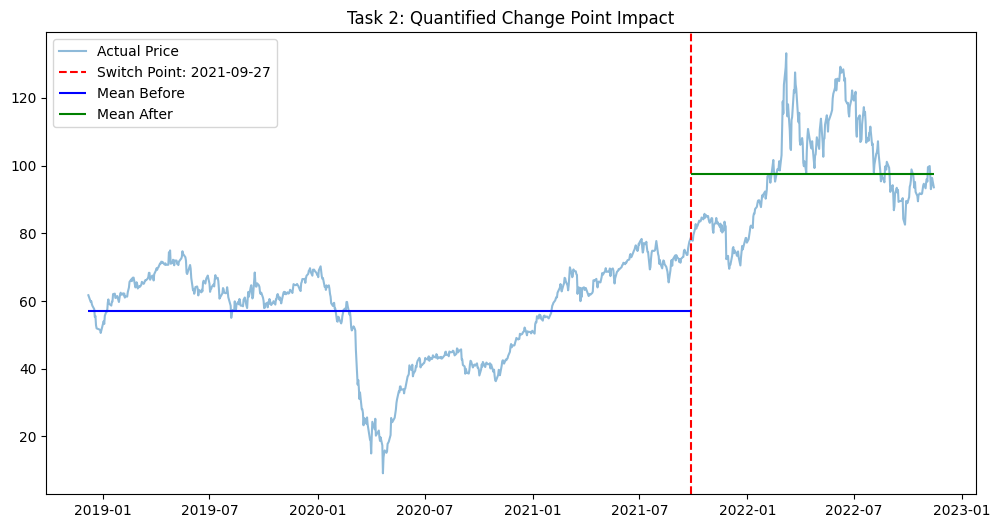

In [5]:
# 1. Identify the most likely date
tau_median = int(np.median(trace.posterior['tau']))
detected_date = dates_subset[tau_median]

# 2. Extract means from posterior
mu1_val = trace.posterior['mu_1'].mean().values
mu2_val = trace.posterior['mu_2'].mean().values
percent_change = ((mu2_val - mu1_val) / mu1_val) * 100

# 3. Print the Final Quantification (Requirement 1.e)
print(f"REPORT SUMMARY:")
print(f"The Bayesian model identifies a structural break on {detected_date.date()}.")
print(f"Market regime shifted from an average of ${mu1_val:.2f} to ${mu2_val:.2f}.")
print(f"This represents a {percent_change:.2f}% change in price level.")

# 4. Visualization for Deliverable
plt.figure(figsize=(12, 6))
plt.plot(dates_subset, data_subset, label='Actual Price', alpha=0.5)
plt.axvline(detected_date, color='red', linestyle='--', label=f'Switch Point: {detected_date.date()}')
plt.hlines(mu1_val, xmin=dates_subset[0], xmax=detected_date, color='blue', label='Mean Before')
plt.hlines(mu2_val, xmin=detected_date, xmax=dates_subset[-1], color='green', label='Mean After')
plt.title('Task 2: Quantified Change Point Impact')
plt.legend()
plt.show()